In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import drive

## Part I

To start, we load the dataset from the .txt file and store the data in a structured manner.

In [2]:
# Connect Google Drive to Colab
drive.mount('/content/drive')

# Define the names of all the columns
noms_columnes = [
    'Num_STAs', 'Load', 'Size_x', 'Size_y', 'Area', 'CW',
    'Channel_width', 'Packet_size', 'Max_RSSI', 'Avg_RSSI', 'Min_RSSI',
    'Avg_Prob_failure', 'Throughput', 'Average_delay', 'Total_airtime', 'Proportional_airtime'
]

# Define the path
ruta_fitxer = '/content/drive/MyDrive/AAX/seminar 1/dataset_Seminar1.txt'

# Load the dataset
df = pd.read_csv(ruta_fitxer, sep='\s+', header=None, names=noms_columnes)

# Visualize first rows
df.head()

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2087/1400220296.py:15: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(ruta_fitxer, sep='\s+', header=None, names=noms_columnes)


Mounted at /content/drive


,Num_STAs,Load,Size_x,Size_y,Area,CW,Channel_width,Packet_size,Max_RSSI,Avg_RSSI,Min_RSSI,Avg_Prob_failure,Throughput,Average_delay,Total_airtime,Proportional_airtime
0,40.0,60000000.0,22.0,39.0,858.0,63.0,80.0,4000.0,-42.928330,-63.163012,-74.965338,0.415189,7.208644e+06,1.229466e+07,1.084041,0.875490
1,35.0,52500000.0,20.0,33.0,660.0,31.0,40.0,10000.0,-47.815800,-63.298410,-72.847989,0.485311,1.545116e+07,1.275042e+07,1.111263,0.873785
2,16.0,12000000.0,34.0,14.0,476.0,255.0,40.0,4000.0,-46.138494,-60.076333,-70.044800,0.099413,6.743660e+06,2.251690e+06,0.880036,0.849701
3,37.0,18500000.0,35.0,7.0,245.0,31.0,80.0,10000.0,-42.708813,-60.141393,-72.029643,0.493704,1.675025e+07,1.211374e+07,1.126341,0.860103
4,18.0,4500000.0,36.0,35.0,1260.0,127.0,160.0,8000.0,-45.492991,-63.780783,-76.225550,0.011664,4.500000e+06,1.446000e-03,0.276770,0.275687


Then we show some of the most representative statistics such as the average of each characteristic or the standard deviation.

In [3]:
# Mostrem estadístiques generals
display(df.describe())

print("\n--- Average of each characteristic ---")
print(df.mean())

print("\n--- Standard deviation ---")
print(df.std())

,Num_STAs,Load,Size_x,Size_y,Area,CW,Channel_width,Packet_size,Max_RSSI,Avg_RSSI,Min_RSSI,Avg_Prob_failure,Throughput,Average_delay,Total_airtime,Proportional_airtime
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,1.000000e+05,100000.000000,100000.000000
mean,21.446170,2.140292e+07,20.562940,20.479640,421.270350,227.043920,75.106000,7997.580000,-45.911165,-57.577426,-66.467827,0.226676,9.716009e+06,4.688176e+06,0.780560,0.660724
std,11.554365,1.852042e+07,11.545206,11.540626,360.344349,323.350855,53.704279,2825.532513,5.400265,6.108548,8.057528,0.224848,4.958025e+06,7.875887e+06,0.360426,0.256756
min,2.000000,5.000000e+05,1.000000,1.000000,1.000000,3.000000,20.000000,4000.000000,-81.405165,-81.405165,-84.333834,0.000209,5.000000e+05,4.930000e-04,0.019793,0.019792
25%,11.000000,7.250000e+06,11.000000,11.000000,120.000000,15.000000,20.000000,6000.000000,-48.131476,-61.985000,-72.637078,0.036429,6.187692e+06,2.145750e-03,0.481082,0.473732
50%,21.000000,1.600000e+07,21.000000,20.000000,320.000000,63.000000,80.000000,8000.000000,-44.111064,-58.163205,-67.997587,0.126492,9.113764e+06,2.253349e+06,0.857473,0.781014
75%,31.000000,3.000000e+07,31.000000,30.000000,640.000000,255.000000,160.000000,10000.000000,-41.888821,-53.589525,-61.525848,0.400686,1.343290e+07,8.224326e+06,1.069432,0.866646
max,41.000000,8.200000e+07,40.000000,40.000000,1600.000000,1023.000000,160.000000,12000.000000,-40.863587,-40.865960,-40.865960,0.765422,2.262273e+07,5.330772e+08,1.449354,0.946776



--- Average of each characteristic ---
Num_STAs                2.144617e+01
Load                    2.140292e+07
Size_x                  2.056294e+01
Size_y                  2.047964e+01
Area                    4.212704e+02
CW                      2.270439e+02
Channel_width           7.510600e+01
Packet_size             7.997580e+03
Max_RSSI               -4.591117e+01
Avg_RSSI               -5.757743e+01
Min_RSSI               -6.646783e+01
Avg_Prob_failure        2.266761e-01
Throughput              9.716009e+06
Average_delay           4.688176e+06
Total_airtime           7.805603e-01
Proportional_airtime    6.607240e-01
dtype: float64

--- Standard deviation ---
Num_STAs                1.155437e+01
Load                    1.852042e+07
Size_x                  1.154521e+01
Size_y                  1.154063e+01
Area                    3.603443e+02
CW                      3.233509e+02
Channel_width           5.370428e+01
Packet_size             2.825533e+03
Max_RSSI                5.400

To continue, we plot the relevant figures to visualize how data is distributed.

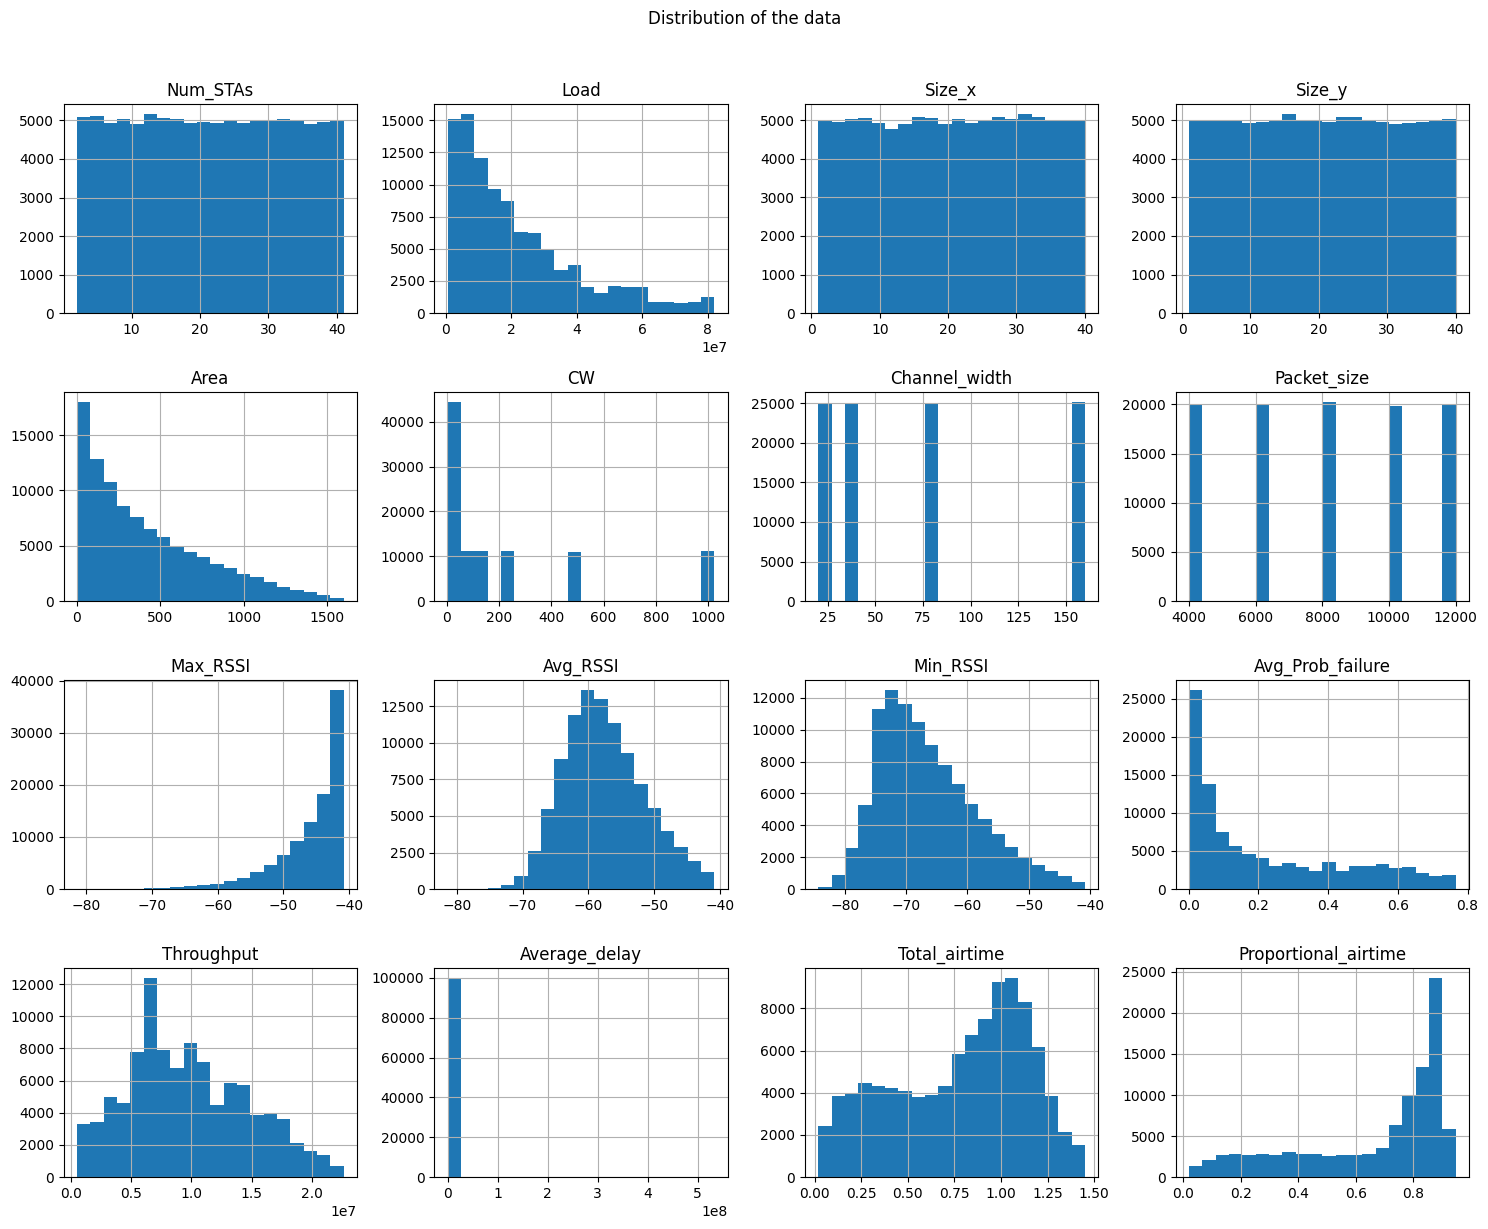

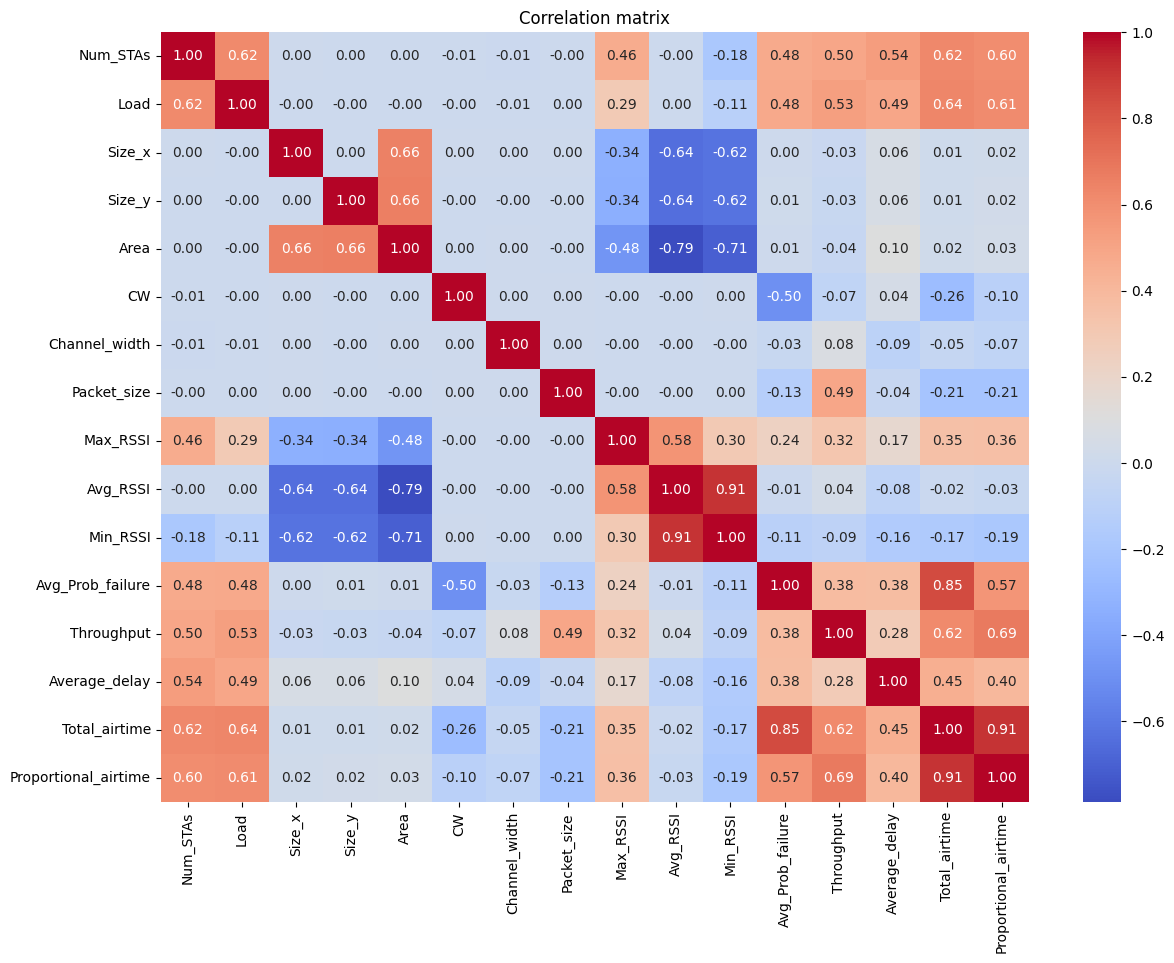

In [4]:
# Histogram of all columns
df.hist(bins=20, figsize=(15, 12))
plt.suptitle('Distribution of the data', y=1.02)
plt.tight_layout()
plt.show()

# Correlation matrix to see which variables are most related
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix')
plt.show()

In the correlation matrix we can see how the attributes are correlated between each other, for example for the Throughput we can observe a strong correlation with the Avg_Prob_failure, Average_delay,
Total_airtime and Proportional_airtime.

To process the data and prepare it to be used by an ML model, we first take the input data as the predictive characteristics ($X$), and as a variable to predict ($y$) we establish the performance or 'Throughput'. After, we split the data into different partitions to be used for training (80%) and testing (20%).

In [5]:
# Cleaning and preparation: We identify all the 'labels' to discard
# We only want to predict the Throughput, the rest of the labels would make the model "cheat"
DISCARD_LABELS = [
    'Avg_Prob_failure',
    'Average_delay',
    'Total_airtime',
    'Proportional_airtime'
]

TARGET_COL = 'Throughput'

# We define 'y' (what we want to predict)
y = df[TARGET_COL].values

# Define 'X' (the input data). Remove Throughput and the other labels
X = df.drop(columns=DISCARD_LABELS + [TARGET_COL]).values

# Normalize the input data (important for Gradient Descent to work well)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data: 80% training and 20% test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape[0]} samples")
print(f"Test shape: {X_test.shape[0]} samples")

Train shape: 80000 samples
Test shape: 20000 samples


## Part II

In this part we have implemented a multivariable linear regression model from scratch using vectorization. We first prepared the data matrices, then we defined the error evaluation metric (Least Squares), and lastly we built the optimization engine (Gradient Descent) to estimate the optimal model coefficients ($\theta$).

In [6]:
# Add a column of ones (1) to the matrix X for the independent term (theta_0)
X_train_b = np.c_[np.ones((len(X_train), 1)), X_train]
X_test_b = np.c_[np.ones((len(X_test), 1)), X_test]

# Define the Cost Function (Least Squares)
def compute_cost(X, y, theta):
    M = len(y)
    predictions = X.dot(theta)
    cost = (1 / (2 * M)) * np.sum(np.square(predictions - y))
    return cost

# Define the optimizer: Gradient Descent
def gradient_descent(X, y, theta, learning_rate, iterations):
    M = len(y)
    cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = X.dot(theta)

        # Calculation of gradients
        gradients = (1 / M) * X.T.dot(predictions - y)

        # Updating weights (theta)
        theta = theta - learning_rate * gradients

        # Keep the cost of this iteration
        cost_history[i] = compute_cost(X, y, theta)

    return theta, cost_history

# Initialize the weights (theta) with random values
np.random.seed(42)
initial_theta = np.random.randn(X_train_b.shape[1])

# Hyperparameters (the learning rate and the number of steps)
learning_rate = 0.1
iterations = 500

# Training
best_theta, cost_history = gradient_descent(X_train_b, y_train, initial_theta, learning_rate, iterations)

print("Training completed!")
print("Estimated final weights:", best_theta)

Training completed!
Estimated final weights: [ 9716740.81404109   896487.94058903  1751376.3265575   -995349.80271001
 -1003445.79182689   731474.76507869  -345726.36399469   418766.03539367
  2441941.83608054   602010.4114663    132600.59876311 -1091963.70024491]


Finally, we plot the results visually:

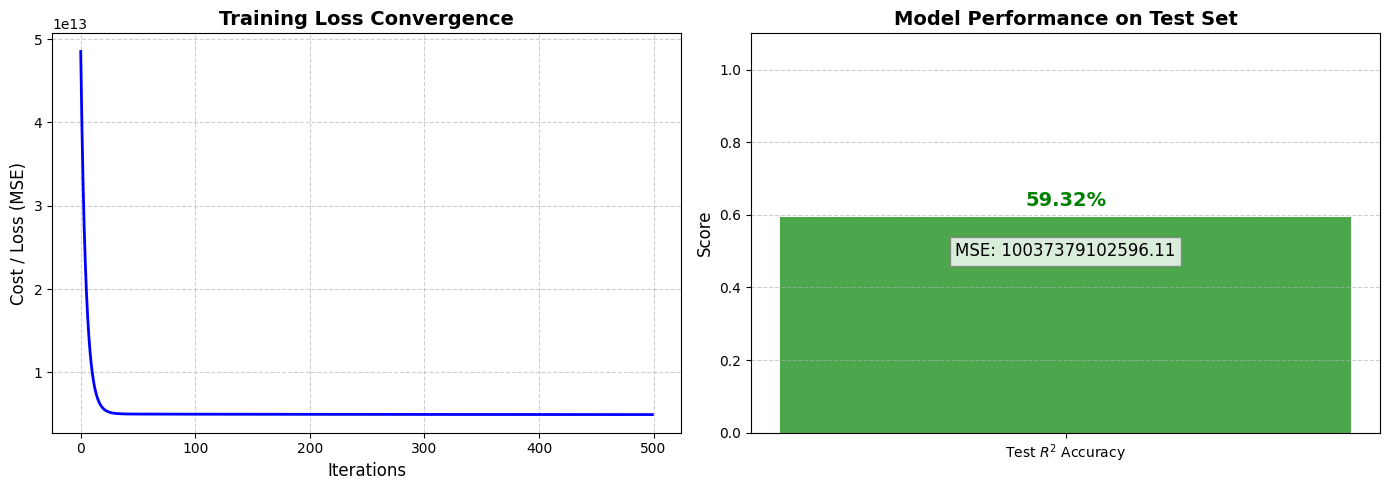

In [7]:
# Calculate the predictions and metrics for the test set
y_pred = X_test_b.dot(best_theta)
mse_test = mean_squared_error(y_test, y_pred)
r2_accuracy = r2_score(y_test, y_pred)

# Create a figure with two subplots next to each other
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: TRAINING LOSS (Left) ---
ax1.plot(cost_history, color='blue', linewidth=2)
ax1.set_title('Training Loss Convergence', fontsize=14, fontweight='bold')
ax1.set_xlabel('Iterations', fontsize=12)
ax1.set_ylabel('Cost / Loss (MSE)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: TEST METRICS / ACCURACY (Right) ---
ax2.bar(['Test $R^2$ Accuracy'], [r2_accuracy], color='green', alpha=0.7, width=0.4)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Model Performance on Test Set', fontsize=14, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.6)

# Add text labels inside the second chart with the exact numerical values
ax2.text(0, r2_accuracy + 0.02, f"{r2_accuracy*100:.2f}%", ha='center', va='bottom', fontsize=14, fontweight='bold', color='green')
ax2.text(0, 0.5, f"MSE: {mse_test:.2f}", ha='center', va='center', fontsize=12, color='black',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Adjust the spacing and display the figure
plt.tight_layout()
plt.show()

After visualizing the results we have seen the following:

- In the left which is the training loss, we can see how by iteration 200, the curve becomes completely horizontal (asymptotic), this means that it converges grately.

- In the right, which is the Accuracy, we can see an $R^2$ coefficient of 59.32% that indicates that the model captures the general trend of network performance, but highlights that Throughput has a highly nonlinear behavior.

With this results we can conclude that the model has limitations because communication networks are complex systems where we can find some interferences that a straight line (linear regression) cannot model 100% of the time.